#### Data gathering

In [15]:
# import all important libraies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


In [16]:
df = pd.read_csv("../datasets/International_education_costs.csv")

df.head()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900,1.35
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650,1.52
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550,0.92


In [17]:
df.describe()

,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
count,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000
mean,2.836825,16705.016538,64.437486,969.206174,211.396913,700.077178,623.000695
std,0.945449,16582.385275,14.056333,517.154752,143.435740,320.374875,3801.746134
min,1.000000,0.000000,27.800000,150.000000,40.000000,200.000000,0.150000
25%,2.000000,2850.000000,56.300000,545.000000,100.000000,450.000000,0.920000
50%,3.000000,7500.000000,67.500000,900.000000,160.000000,650.000000,1.350000
75%,4.000000,31100.000000,72.200000,1300.000000,240.000000,800.000000,7.150000
max,5.000000,62000.000000,122.400000,2500.000000,490.000000,1500.000000,42150.000000


In [18]:
print(df.shape)
df.info()

(907, 12)
<class 'pandas.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            907 non-null    str    
 1   City               907 non-null    str    
 2   University         907 non-null    str    
 3   Program            907 non-null    str    
 4   Level              907 non-null    str    
 5   Duration_Years     907 non-null    float64
 6   Tuition_USD        907 non-null    int64  
 7   Living_Cost_Index  907 non-null    float64
 8   Rent_USD           907 non-null    int64  
 9   Visa_Fee_USD       907 non-null    int64  
 10  Insurance_USD      907 non-null    int64  
 11  Exchange_Rate      907 non-null    float64
dtypes: float64(3), int64(4), str(5)
memory usage: 135.6 KB


In [19]:
## isnull() --> to check if we are having any missing value in the dataframe or not
## duplicated() --> to check if we have duplicate rows or not

df.isnull()
df.isnull().sum()

df.duplicated()
df.duplicated().sum()

np.int64(0)

#### Data Exploration

In [23]:
df['Country'].value_counts().head(10)

Country
UK             93
Australia      86
USA            78
Canada         76
Germany        33
France         27
South Korea    23
Netherlands    21
Switzerland    20
Singapore      18
Name: count, dtype: int64

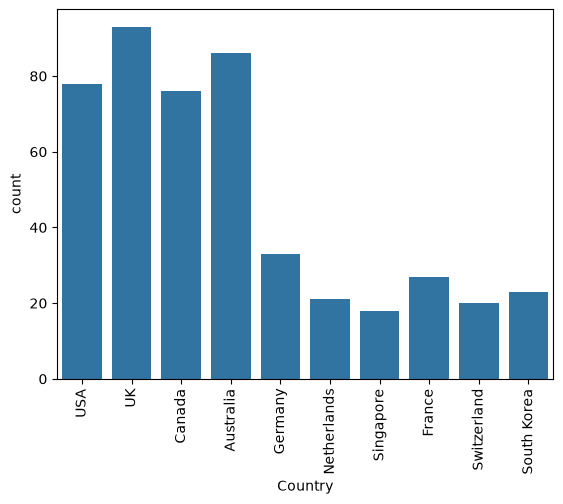

In [25]:
country = df[df['Country'].isin(['UK','Australia','USA','Canada','Germany','France','South Korea','Netherlands','Switzerland','Singapore'])]

sns.countplot(data=country, x='Country')
plt.xticks(rotation='vertical')
plt.show()

[]

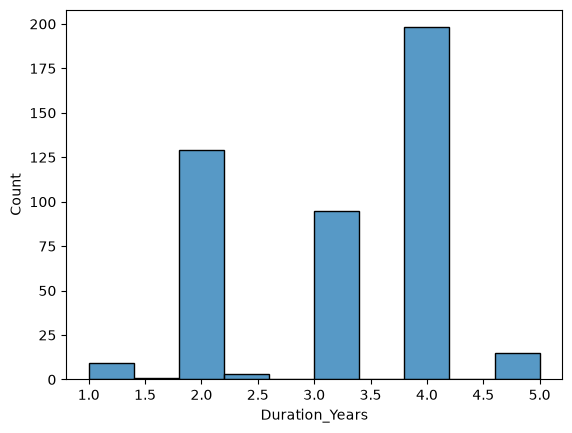

In [27]:
d1 = df[df['Level']== 'Master'].head(150)
d2 = df[df['Level']== 'Bachelor'].head(150)
d3 = df[df['Level']== 'PhD'].head(150)

d4 = pd.concat([d1, d2, d3])
d4.shape

sns.histplot(data=d4, x = 'Duration_Years')
plt.plot()

#### Feature Engineering

In [31]:
df['Total_Cost'] = df['Tuition_USD'] + df['Rent_USD']
df.head()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate,Total_Cost
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00,57600
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79,43000
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900,1.35,40100
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650,1.52,43400
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550,0.92,1600


#### Feature Selection

In [35]:
df = df[['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years', 'Living_Cost_Index','Visa_Fee_USD', 'Insurance_USD', 'Total_Cost']]

print(df.shape)
df.head()

(907, 10)


,Country,City,University,Program,Level,Duration_Years,Living_Cost_Index,Visa_Fee_USD,Insurance_USD,Total_Cost
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,83.5,160,1500,57600
1,UK,London,Imperial College London,Data Science,Master,1.0,75.8,485,800,43000
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,72.5,235,900,40100
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,71.2,450,650,43400
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,70.5,75,550,1600


In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Country'] = le.fit_transform(df['Country'])
df['City'] = le.fit_transform(df['City'])
df['University'] = le.fit_transform(df['University'])
df['Program'] = le.fit_transform(df['Program'])
df['Level'] = le.fit_transform(df['Level'])
df['Duration_Years'] = le.fit_transform(df['Duration_Years'])
df['Living_Cost_Index'] = le.fit_transform(df['Living_Cost_Index'])
df['Visa_Fee_USD'] = le.fit_transform(df['Visa_Fee_USD'])
df['Insurance_USD'] = le.fit_transform(df['Insurance_USD'])
df['Total_Cost'] = le.fit_transform(df['Total_Cost'])

df.head()

,Country,City,University,Program,Level,Duration_Years,Living_Cost_Index,Visa_Fee_USD,Insurance_USD,Total_Cost
0,66,84,101,17,1,2,195,15,19,527
1,65,283,128,27,1,0,174,28,15,480
2,9,503,572,9,1,2,156,20,17,463
3,2,313,495,44,1,2,148,27,11,483
4,22,330,307,66,1,2,146,3,9,39


In [ ]:
## Seperate input and output data
X = df.iloc[:, :9]
Y = df['Total_Cost']


In [43]:
## FEATURE SCALING

from sklearn.preprocessing import StandardScaler

s = StandardScaler()
X = s.fit_transform(X)
X

array([[ 1.29937861, -1.18314994, -1.25623694, ...,  1.4291556 ,
        -0.01738315,  1.49765747],
       [ 1.25678296,  0.02539721, -1.10697039, ...,  1.03686382,
         1.52370499,  0.71899577],
       [-1.12857335,  1.3614795 ,  1.3476352 , ...,  0.70061372,
         0.57534306,  1.10832662],
       ...,
       [ 0.66044389, -1.62041323, -0.96323222, ..., -0.1026504 ,
         0.33825257,  0.71899577],
       [ 1.29937861,  0.98494722,  1.41950429, ...,  1.14894719,
        -0.01738315,  1.49765747],
       [ 1.25678296,  0.4140757 ,  1.01593175, ..., -0.36417826,
         1.52370499,  0.71899577]], shape=(907, 9))

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(X_train.shape) # 80% of input data
print(X_test.shape)  # 20% of input data
print(Y_train.shape) # 80% of output data
print(Y_test.shape)  # 20% of output data

(725, 9)
(182, 9)
(725,)
(182,)


### Model training and Evalution